## An autoencoder implementation for fraud detection

In [2]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch 
import torch.nn as nn

In [27]:
df = pd.read_csv('../Data/processed/processed_data.csv')
fraud_df = df.copy()
labels = fraud_df['class'].values
fraud_df = fraud_df.drop(['country', 'class','user_id', 'signup_time', 'purchase_time'], axis=1)
fraud_df.head()

,purchase_value,device_id,source,browser,sex,age,ip_address,lower_bound_ip_address,upper_bound_ip_address,hour_of_day,day_of_week,time_since_signup,device_count,ip_count
0,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093,NaN,NaN,10,6,1763014.0,1,1
1,33,YFGYOALADBHLT,Ads,IE,F,30,93447,NaN,NaN,17,4,1084823.0,1,1
2,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818,NaN,NaN,8,1,749320.0,1,1
3,33,PIBUQMBIELMMG,Ads,IE,M,40,117566,NaN,NaN,21,3,7434634.0,1,1
4,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423,NaN,NaN,7,6,1407619.0,1,1


#### encoding and scaling 

In [32]:
def encode_scale(df, labels):
    # Split
    X_train, X_test,  y_train, y_test= train_test_split(df,labels, test_size=0.2, random_state=42)
    
    # Encode Categorical
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
    train_enc_arr = encoder.fit_transform(X_train[cat_cols])
    
    # Get names AFTER fitting
    encoded_cols = encoder.get_feature_names_out(cat_cols)
    
    # Create DataFrames
    X_train_cat = pd.DataFrame(train_enc_arr, columns=encoded_cols, index=X_train.index)
    X_test_cat = pd.DataFrame(encoder.transform(X_test[cat_cols]), columns=encoded_cols, index=X_test.index)

    # Scale Numerical
    scaler = StandardScaler()
    X_train_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
    X_test_num = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

    # Combine
    X_train_final = pd.concat([X_train_cat, X_train_num], axis=1)
    X_test_final = pd.concat([X_test_cat, X_test_num], axis=1)

    print("-" * 20)
    print("Encoding & Scaling Completed")
    print("-" * 20)
    
    return X_train_final, X_test_final,  y_train, y_test, scaler

In [35]:
## columns to train with 
cat_cols = ['source', 'browser', 'sex'] 
num_cols =  ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_count', 'ip_count']

In [36]:
X_train, X_test,y_train, y_test, scaler = encode_scale(fraud_df, labels)

--------------------
Encoding & Scaling Completed
--------------------


#### convert into pytorch tensors

In [38]:
X_train_ts = torch.tensor(X_train.values, dtype=torch.float32)
X_test_ts = torch.tensor(X_test.values, dtype=torch.float32)
y_train_ts = torch.tensor(y_train, dtype=torch.float32)
y_test_ts = torch.tensor(y_test, dtype=torch.float32)

X_train_normal = X_train_ts[y_train_ts == 0]

### build the autoencoder model 

In [41]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### train the autoencoder

In [42]:
input_dim = X_train_normal.shape[1]
autoencoder = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

num_epochs = 50
batch_size = 128
train_data = X_train_normal

print(f"Starting training on {len(train_data)} normal transactions...")

for epoch in range(num_epochs):
    autoencoder.train()
    epoch_loss = 0
    
    # Shuffle indices manually for better training stability
    permutation = torch.randperm(train_data.size(0))
    
    for i in range(0, len(train_data), batch_size):
        indices = permutation[i : i + batch_size]
        batch = train_data[indices]
        
        # Forward pass
        output = autoencoder(batch)
        loss = criterion(output, batch) # Reconstruction error
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(train_data) / batch_size)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Avg Reconstruction Loss: {avg_loss:.6f}')

print("Training Complete.")


Starting training on 109635 normal transactions...
Epoch [1/50], Avg Reconstruction Loss: 0.060693
Epoch [5/50], Avg Reconstruction Loss: 0.003458
Epoch [10/50], Avg Reconstruction Loss: 0.003165
Epoch [15/50], Avg Reconstruction Loss: 0.002043
Epoch [20/50], Avg Reconstruction Loss: 0.001336
Epoch [25/50], Avg Reconstruction Loss: 0.001042
Epoch [30/50], Avg Reconstruction Loss: 0.000584
Epoch [35/50], Avg Reconstruction Loss: 0.000523
Epoch [40/50], Avg Reconstruction Loss: 0.000499
Epoch [45/50], Avg Reconstruction Loss: 0.000490
Epoch [50/50], Avg Reconstruction Loss: 0.000474
Training Complete.


### Evaluating the model

In [46]:
autoencoder.eval()

with torch.no_grad():
    # Pass the test tensor through the model
    predictions_ts = autoencoder(X_test_ts)
    
    # Calculate MSE per row (dim=1)
    # Higher error = higher likelihood of fraud
    mse_per_row = torch.mean((X_test_ts - predictions_ts)**2, dim=1)

# Convert to a numpy array for classification
reconstruction_errors = mse_per_row.cpu().numpy()

In [49]:
# Use the 95th percentile as a threshold (can be adjusted)
threshold = np.percentile(reconstruction_errors, 85)
print(f"Threshold for anomaly detection: {threshold:.6f}")

# Any error above threshold is classified as Fraud (1), below as Normal (0)
y_pred = (reconstruction_errors > threshold).astype(int)

Threshold for anomaly detection: 0.000232


In [50]:
# Ensure y_test is a numpy array
y_test_np = y_test_ts.cpu().numpy()

# Print the final metrics
print("--- Classification Report ---")
print(classification_report(y_test_np, y_pred, target_names=['Normal', 'Fraud']))


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.96      0.90      0.93     27326
       Fraud       0.42      0.65      0.51      2897

    accuracy                           0.88     30223
   macro avg       0.69      0.78      0.72     30223
weighted avg       0.91      0.88      0.89     30223



### Visualize Reconnstruction error

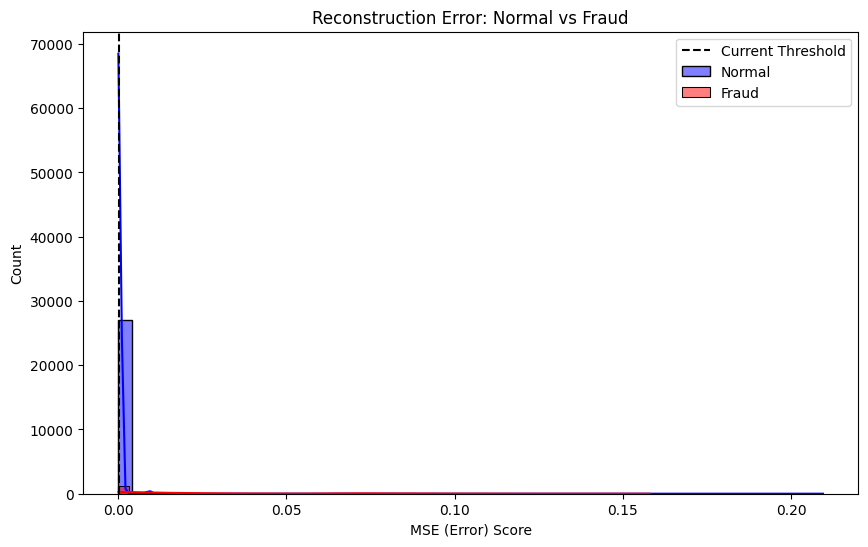

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Use 'reconstruction_errors' instead of 'mse_test'
sns.histplot(reconstruction_errors[y_test_ts.numpy() == 0], bins=50, color='blue', label='Normal', kde=True)
sns.histplot(reconstruction_errors[y_test_ts.numpy() == 1], bins=50, color='red', label='Fraud', kde=True)

plt.axvline(threshold, color='black', linestyle='--', label='Current Threshold')
plt.title('Reconstruction Error: Normal vs Fraud')
plt.xlabel('MSE (Error) Score')
plt.legend()
plt.show()